# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Demo Notebook: Geospatial Viz, Feature Importance, Uncertainty & Dashboards

topics:

1. Why Visualize Data Geographically?
2. From Location to Coordinates
3. The Map Projection Problem
4. Building a Map: Layers and Context
5. Point Maps
6. Symbol Maps
7. Choropleth Maps
8. The Choropleth Trap: Counts vs. Rates
9. Cartograms
10. Choosing the Right Geospatial Visualization
11. What Is Feature Importance?
12. From Importance to Visual Encoding
13. Global vs. Local Feature Importance
14. Positive and Negative Contributions
15. Feature Importance Is Not the Same as Feature Effect
16. Uncertainty Visualization
17. Variation, Standard Error & Confidence Intervals (worked example)
18. Error Bars & Reading Confidence Intervals
19. Bayesian Uncertainty: Credible Intervals & Distributions
20. Uncertainty in Trend Lines
21. Communicating Uncertainty Through Possible Outcomes (HOPs)
22. Interactive Dashboards
23. Dashboard Information Density & Composite Visualizations
24. Coordinated Multiple Views & Brushing/Linking

**Dataset:** Gapminder (`plotly.express.data.gapminder()`) — 142 countries, 1952–2007
(every 5 years), with `lifeExp`, `pop`, `gdpPercap`, `continent`, and ISO country codes.
Real country boundary data (a public world GeoJSON) is used to compute real country
centroids for the point-map section.

In [ ]:
# If a package below is missing in your environment, uncomment the next line:
# %pip install -q plotly scikit-learn shap ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)
print("Libraries loaded.")

Libraries loaded.


## 0. The Running Dataset

In [ ]:
gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")

gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
print(f"Gapminder: {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}")
print(f"2007 snapshot with real centroids: {gap_latest.centroid_lat.notna().sum()} of {len(gap_latest)} countries matched.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap", "iso_alpha"]].head()

Gapminder: 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
2007 snapshot with real centroids: 135 of 142 countries matched.


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha
0,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG
1,Albania,Europe,2007,76.423,3600523,5937.029526,ALB
2,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA
3,Angola,Africa,2007,42.731,12420476,4797.231267,AGO
4,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG


## 1. Why Visualize Data Geographically?  *(Slide 4)*

**What:** Geospatial visualization represents data according to its **location**. A map
becomes useful when *where* something occurs is part of the question — revealing spatial
patterns, clusters/hotspots, regional differences, and geographic context that a table
can't.

**Why:** Below, the exact same `lifeExp` values are shown as a plain sorted bar chart
(no location) and as a world map (location front and center) — the map immediately
reveals a *regional* pattern (a life-expectancy gap concentrated in Sub-Saharan Africa)
that the bar chart leaves the viewer to reconstruct manually.

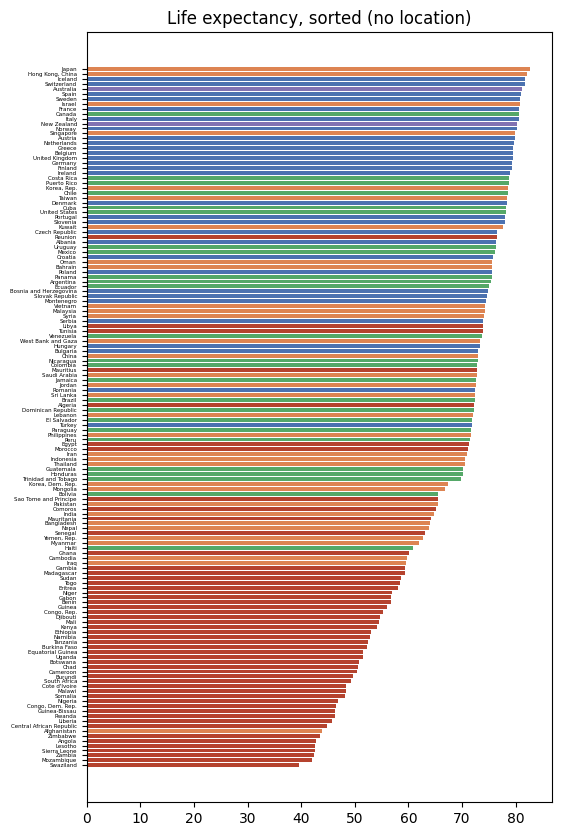

In [ ]:
fig, ax = plt.subplots(figsize=(6, 10))
ordered = gap_latest.sort_values("lifeExp")
colors = ordered.continent.map({"Africa": "#b5432e", "Asia": "#DD8452", "Europe": "#4C72B0",
                                 "Americas": "#55A868", "Oceania": "#8172B2"})
ax.barh(ordered.country, ordered.lifeExp, color=colors)
ax.tick_params(axis="y", labelsize=4)
ax.set_title("Life expectancy, sorted (no location)")
plt.show()

fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="lifeExp",
                      hover_name="country", color_continuous_scale="RdYlGn",
                      title="Life expectancy, on a map -- the regional pattern is immediate")
fig2.show()

## 2. From Location to Coordinates  *(Slide 5)*

**What:** To visualize geographic data, locations must first be numeric: **latitude**
(−90° to +90°) and **longitude** (−180° to +180°). A geographic coordinate system
describes positions on a sphere; a screen is flat — this mismatch is the fundamental
problem of **map projection** (Section 3).

**Why:** Below, we compute real centroid coordinates for every country directly from
public boundary (GeoJSON) polygon data — turning "Brazil" into a literal (lon, lat)
number pair we can plot.

         country  centroid_lon  centroid_lat
    Burkina Faso     -1.850361     12.092760
      Madagascar     46.989215    -17.971485
            Iran     53.416020     33.400097
     Netherlands      5.585888     52.158607
         Austria     13.484573     47.644699
         Finland     25.771844     65.477076
Congo, Dem. Rep.     23.013604     -3.771089
          Greece     23.559379     38.885048


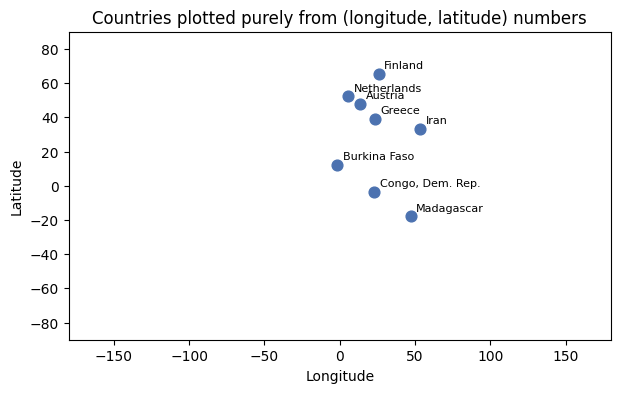

In [ ]:
sample = gap_latest.dropna(subset=["centroid_lat"]).sample(8, random_state=3)
print(sample[["country", "centroid_lon", "centroid_lat"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sample.centroid_lon, sample.centroid_lat, s=60, color="#4C72B0")
for _, row in sample.iterrows():
    ax.annotate(row.country, (row.centroid_lon, row.centroid_lat), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Countries plotted purely from (longitude, latitude) numbers")
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
plt.show()

## 3. The Map Projection Problem  *(Slides 6–7)*

**What:** The Earth is a sphere; displays are flat. Every projection distorts at least
one of **shape, area, distance, direction** — no projection preserves all four.
Design principle: choose the projection to match the *purpose* (area-preserving for
comparing regional quantities, direction-preserving for navigation, etc.).

**Why:** Below, the same choropleth is rendered under three different projections —
notice how country *sizes* (especially near the poles) visibly change between them,
even though the underlying `lifeExp` data hasn't changed at all.

In [ ]:
for proj in ["orthographic", "mercator", "natural earth"]:
    fig = px.choropleth(gap_latest, locations="iso_alpha", color="lifeExp",
                         hover_name="country", color_continuous_scale="RdYlGn",
                         projection=proj, title=f"Projection: {proj}")
    fig.show()

print("Same data, same colors -- but relative country SIZES change noticeably by projection,")
print("especially at high latitudes (compare Greenland/Russia across the three views).")

Same data, same colors -- but relative country SIZES change noticeably by projection,
especially at high latitudes (compare Greenland/Russia across the three views).


## 4. Building a Map: Layers and Context  *(Slide 8)*

**What:** A useful map is rarely one layer. **Base** layer (terrain/land/water),
**reference** layers (roads, boundaries, cities), **data** layer (the actual
observations) — every layer should serve the analytical task, or it becomes clutter.

**Why:** Below, the same point map is shown with a cluttered base (unnecessary
graticule/frame decoration) vs. a clean base (just coastlines + the data) — the data
layer is identical in both.

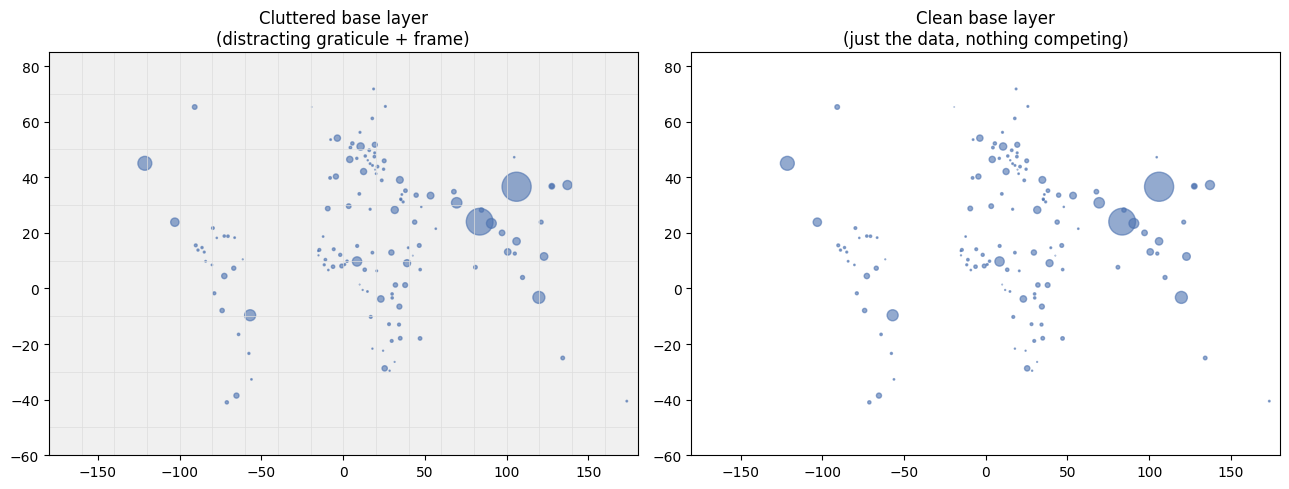

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample2 = gap_latest.dropna(subset=["centroid_lat"])

for ax, cluttered in zip(axes, [True, False]):
    ax.scatter(sample2.centroid_lon, sample2.centroid_lat, s=sample2["pop"]/3e6, alpha=0.6, color="#4C72B0")
    if cluttered:
        for gl in range(-180, 181, 20):
            ax.axvline(gl, color="#dddddd", lw=0.5)
        for gl in range(-90, 91, 20):
            ax.axhline(gl, color="#dddddd", lw=0.5)
        ax.set_facecolor("#f0f0f0")
        ax.set_title("Cluttered base layer\n(distracting graticule + frame)")
    else:
        ax.set_title("Clean base layer\n(just the data, nothing competing)")
        ax.set_facecolor("white")
    ax.set_xlim(-180, 180); ax.set_ylim(-60, 85)

plt.tight_layout()
plt.show()

## 5. Point Maps: Where Are the Observations?  *(Slide 9)*

**What:** A point map encodes **position -> geographic location** directly. Additional
attributes can layer on via color, size, shape, transparency. Strength: shows exact
locations; limitation: overplotting when observations overlap.

**Why:** Below, every country is plotted at its real centroid, with point size
encoding population — Bangladesh and India visibly dominate purely through the size
channel.

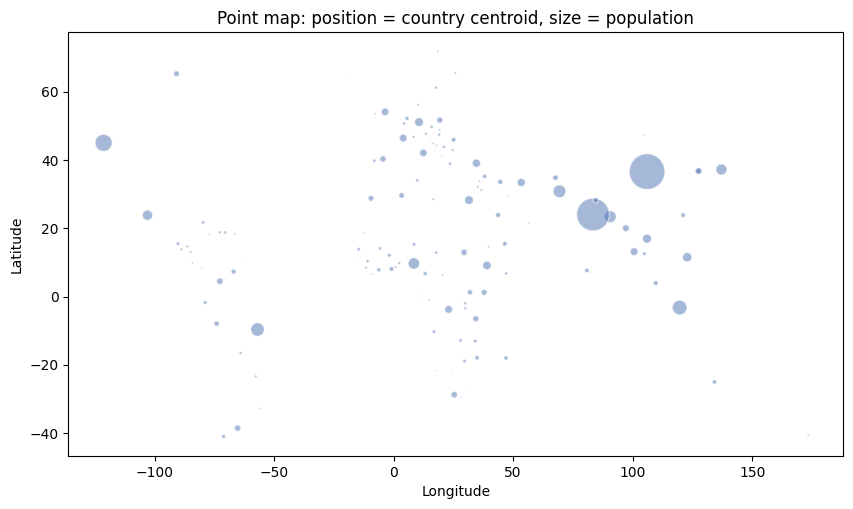

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
d = gap_latest.dropna(subset=["centroid_lat"])
sc = ax.scatter(d.centroid_lon, d.centroid_lat, s=d["pop"]/2e6, alpha=0.5, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Point map: position = country centroid, size = population")
plt.show()

## 6. Symbol Maps: Adding Another Dimension  *(Slide 10)*

**What:** A symbol map layers multiple encodings onto each point: size -> magnitude,
color -> category/value, shape -> type. This produces a genuinely **multivariate**
spatial visualization from a single map.

**Why:** Below, the same country points now encode THREE variables at once: position
(location), size (population), and color (continent) — three separate visual queries
answerable from one figure.

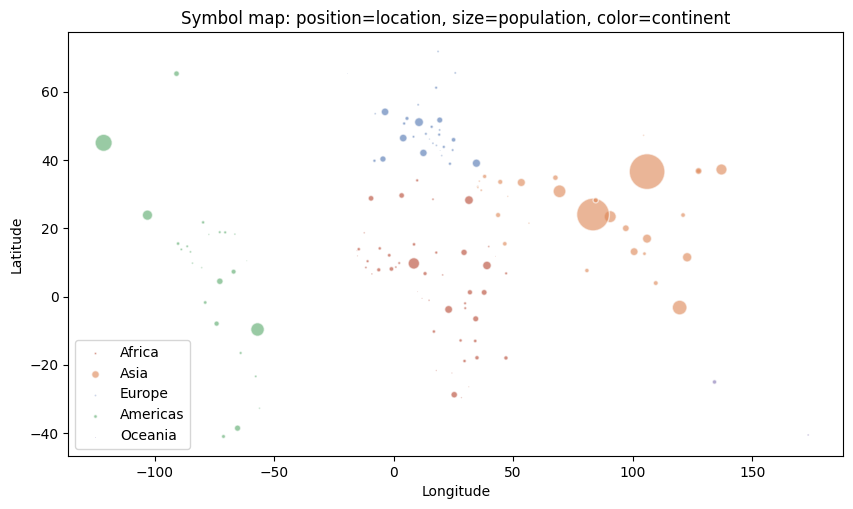

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
continent_colors = {"Africa": "#b5432e", "Asia": "#DD8452", "Europe": "#4C72B0",
                     "Americas": "#55A868", "Oceania": "#8172B2"}
for cont, color in continent_colors.items():
    sub = d[d.continent == cont]
    ax.scatter(sub.centroid_lon, sub.centroid_lat, s=sub["pop"]/2e6, alpha=0.6,
               color=color, edgecolor="white", label=cont)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Symbol map: position=location, size=population, color=continent")
ax.legend(markerscale=0.3, loc="lower left")
plt.show()

## 7. Choropleth Maps  *(Slide 12)*

**What:** A choropleth divides space into predefined regions and uses **color** to show
a quantitative value per region. ENCODING: region -> geographic area, color ->
quantitative value.

**Why:** Below, GDP per capita by country — regional wealth patterns (Western
Europe/North America vs. much of Sub-Saharan Africa) are visible in a single glance.

In [ ]:
fig = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                     hover_name="country", color_continuous_scale="Viridis",
                     title="Choropleth: GDP per capita by country, 2007")
fig.show()

## 8. The Choropleth Trap: Counts vs. Rates  *(Slides 13–14)*

**What:** Raw **counts** are misleading on a choropleth — a region with more people
naturally has bigger raw totals, regardless of its actual rate. The lecture's own
example: a median-income choropleth is visually dominated by a huge but sparsely
populated region (Alaska), while densely populated high-income regions barely register.

**Why:** Below is our dataset's version of exactly this trap: total GDP (`pop *
gdpPercap`, a "count"-like aggregate) vs. GDP **per capita** (a rate). The two maps tell
almost opposite stories about which countries "matter" economically.

In [ ]:
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

fig1 = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp",
                      hover_name="country", color_continuous_scale="Reds",
                      title="BAD framing -- Total GDP (a 'count'): dominated by sheer population size")
fig1.show()

fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                      hover_name="country", color_continuous_scale="Reds",
                      title="BETTER framing -- GDP per Capita (a 'rate'): reveals actual prosperity")
fig2.show()

top_total = gap_latest.nlargest(3, "total_gdp")[["country", "total_gdp", "gdpPercap"]]
top_rate = gap_latest.nlargest(3, "gdpPercap")[["country", "total_gdp", "gdpPercap"]]
print("Top 3 by TOTAL GDP (dominated by population size):\n", top_total.to_string(index=False))
print("\nTop 3 by GDP PER CAPITA (the actual prosperity rate):\n", top_rate.to_string(index=False))
print("\nNotice these are almost entirely DIFFERENT countries -- exactly the counts-vs-rates trap.")

Top 3 by TOTAL GDP (dominated by population size):
       country    total_gdp    gdpPercap
United States 1.293446e+13 42951.653090
        China 6.539501e+12  4959.114854
        Japan 4.035135e+12 31656.068060

Top 3 by GDP PER CAPITA (the actual prosperity rate):
   country    total_gdp   gdpPercap
   Norway 2.284214e+11 49357.19017
   Kuwait 1.185305e+11 47306.98978
Singapore 2.146433e+11 47143.17964

Notice these are almost entirely DIFFERENT countries -- exactly the counts-vs-rates trap.


## 9. Cartograms: Distorting Geography to Encode Data  *(Slides 15–16)*

**What:** A cartogram deliberately resizes regions so that **area encodes a variable**
(e.g. population) instead of true geographic area — trading recognizable geography for
data prominence. Trade-off: important quantities become visually prominent, but shape/
location become harder to recognize.

**Why:** Below, a simple bubble-style cartogram sizes each country by population
(instead of true land area) while color still encodes GDP per capita — India and China
become visually dominant, exactly as the lecture describes, even though their
*geographic* area on a real map is unremarkable by comparison to, say, Russia.

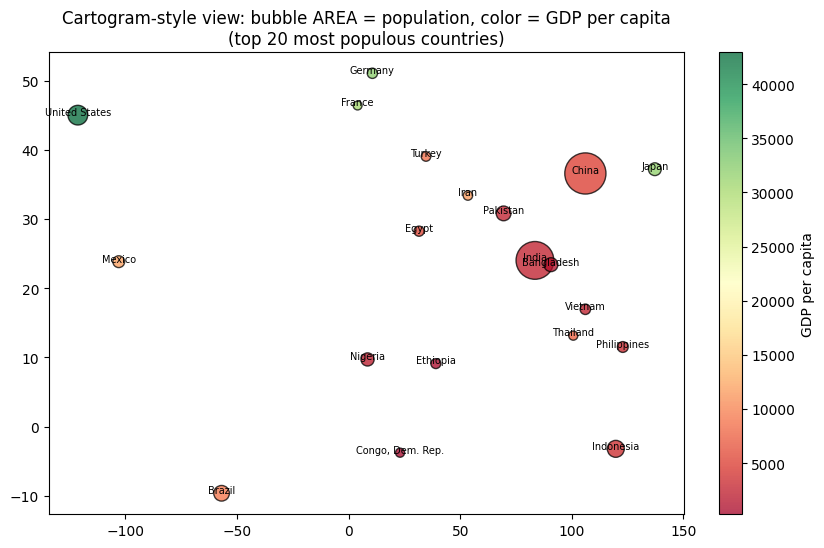

In [ ]:
top20 = gap_latest.dropna(subset=["centroid_lat"]).nlargest(20, "pop")

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(top20.centroid_lon, top20.centroid_lat, s=top20["pop"]/1.5e6,
                 c=top20.gdpPercap, cmap="RdYlGn", alpha=0.75, edgecolor="black")
for _, row in top20.iterrows():
    ax.annotate(row.country, (row.centroid_lon, row.centroid_lat), fontsize=7, ha="center")
plt.colorbar(sc, ax=ax, label="GDP per capita", fraction=0.04)
ax.set_title("Cartogram-style view: bubble AREA = population, color = GDP per capita\n(top 20 most populous countries)")
plt.show()

## 10. Choosing the Right Geospatial Visualization  *(Slide 17)*

| Data situation | Best choice |
|---|---|
| Individual locations | Point map |
| Quantity by region | Choropleth |
| Magnitude at locations | Symbol map |
| Density of observations | Dot-density map |
| Quantity should determine visual size | Cartogram |

Ask: **What does the viewer need to do** (locate / compare / detect hotspots / understand
context)? And **what must not be sacrificed** (accurate interpretation, appropriate
color scale, geographic context, readability)?

## 11. What Is Feature Importance?  *(Slide 18)*

**What:** In a predictive model, different input features contribute differently to
the output. Feature importance visualization communicates which features matter most,
their relative importance, and which deserve further investigation. Two levels:
**global** (importance across the whole model) and **local** (importance for one
specific prediction).

**Why:** Below, we fit a real model — predicting `lifeExp` from `gdpPercap`, `pop`, and
`year` — then extract and visualize its global feature importances.

In [ ]:
model_df = gapminder.copy()
X_model = model_df[["gdpPercap", "pop", "year"]].values
y_model = model_df["lifeExp"].values

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)
rf.fit(X_model, y_model)

importances = pd.Series(rf.feature_importances_, index=["gdpPercap", "pop", "year"]).sort_values()
print(f"Model R^2 on training data: {rf.score(X_model, y_model):.3f}")
importances

Model R^2 on training data: 0.833


pop          0.065705
year         0.096958
gdpPercap    0.837337
dtype: float64

## 12. From Importance to Visual Encoding  *(Slides 19–21)*

**What:** Once importance is computed, HOW should it be encoded visually? **Position/
length** on a common scale is a much stronger quantitative channel than color alone —
"long bar vs. short bar" communicates magnitude far more directly than "dark purple vs.
light purple."

**Why:** Below, the same 3 importance values are shown twice: once as color intensity
alone (hard to compare precisely) and once as bar length (easy to compare precisely).

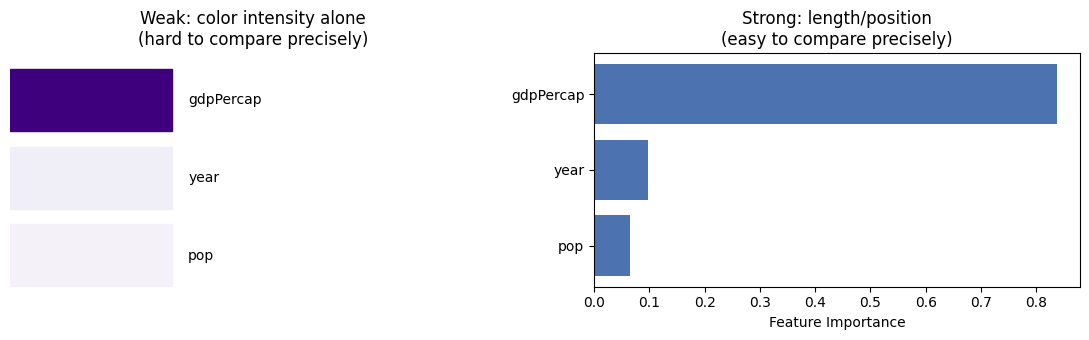

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Weak encoding: color intensity only
for i, (feat, val) in enumerate(importances.items()):
    axes[0].add_patch(mpatches.Rectangle((0, i), 1, 0.8, color=plt.cm.Purples(val / importances.max())))
    axes[0].text(1.1, i + 0.4, feat, va="center", fontsize=10)
axes[0].set_xlim(0, 3); axes[0].set_ylim(0, len(importances))
axes[0].axis("off")
axes[0].set_title("Weak: color intensity alone\n(hard to compare precisely)")

# Strong encoding: length/position
axes[1].barh(importances.index, importances.values, color="#4C72B0")
axes[1].set_title("Strong: length/position\n(easy to compare precisely)")
axes[1].set_xlabel("Feature Importance")

plt.tight_layout()
plt.show()

## 13. Global vs. Local Feature Importance  *(Slide 22)*

**What:**
- **Global importance:** which features generally influence the model? Useful for
  understanding the model overall, feature selection, comparing reliance on inputs.
- **Local importance:** which features influenced THIS particular prediction? Useful for
  explaining individual decisions, investigating unusual predictions.

**Why:** Below, global importance (already computed in Section 11) is compared against
the **local** importance for two specific countries with very different predicted life
expectancies — using SHAP values, which decompose one prediction into per-feature
contributions.

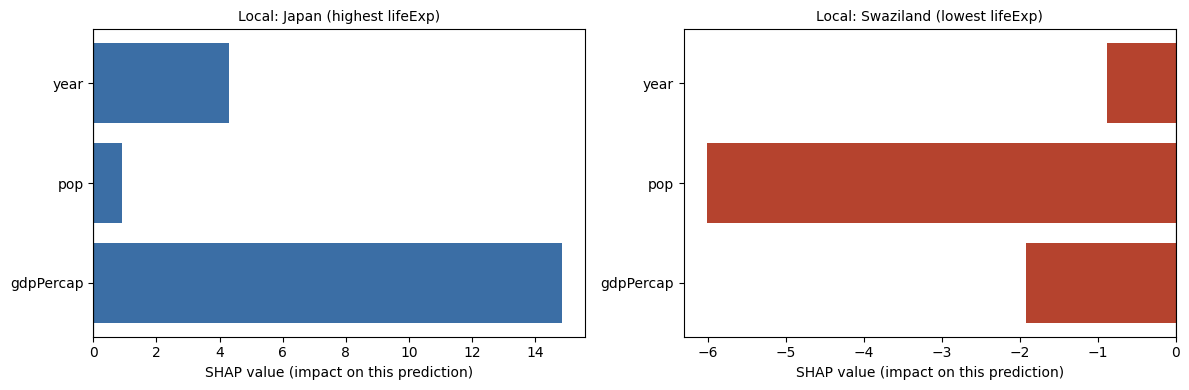

Compare this to the GLOBAL importances from Section 11 -- global importance told us
'gdpPercap generally matters most'; local importance tells us exactly how much, and in
which direction, gdpPercap pushed each of THESE two specific predictions.


In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# Pick two contrasting real rows: a high-lifeExp and a low-lifeExp country in 2007
row_high = model_df[(model_df.year == 2007)].nlargest(1, "lifeExp").index[0]
row_low = model_df[(model_df.year == 2007)].nsmallest(1, "lifeExp").index[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, row_idx, title in zip(axes, [row_high, row_low],
                                [f"Local: {model_df.loc[row_high, 'country']} (highest lifeExp)",
                                 f"Local: {model_df.loc[row_low, 'country']} (lowest lifeExp)"]):
    vals = shap_values[row_idx]
    colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
    ax.barh(["gdpPercap", "pop", "year"], vals, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("SHAP value (impact on this prediction)")

plt.tight_layout()
plt.show()

print("Compare this to the GLOBAL importances from Section 11 -- global importance told us")
print("'gdpPercap generally matters most'; local importance tells us exactly how much, and in")
print("which direction, gdpPercap pushed each of THESE two specific predictions.")

## 14. Positive and Negative Contributions  *(Slide 23)*

**What:** A feature can push a prediction UP or DOWN. A simple magnitude ranking
(`Feature A = 0.8`) doesn't communicate direction. **Diverging horizontal bar charts**
encode direction explicitly.

**Why:** Below, all 3 features' SHAP contributions for one country are shown as a
diverging bar chart — immediately answering not just "how much" but "which way.\"

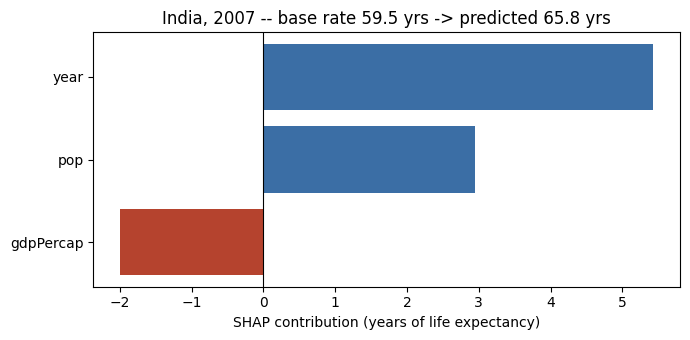

Green/blue bars push the prediction UP from the base rate; red bars push it DOWN --
a ranking of |values| alone would have hidden this directional story completely.


In [ ]:
row_idx = model_df[(model_df.country == "India") & (model_df.year == 2007)].index[0]
vals = shap_values[row_idx]
base = float(np.ravel(explainer.expected_value)[0])
pred = float(rf.predict(X_model[[row_idx]])[0])

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(["gdpPercap", "pop", "year"], vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP contribution (years of life expectancy)")
ax.set_title(f"India, 2007 -- base rate {base:.1f} yrs -> predicted {pred:.1f} yrs")
plt.tight_layout()
plt.show()

print("Green/blue bars push the prediction UP from the base rate; red bars push it DOWN --")
print("a ranking of |values| alone would have hidden this directional story completely.")

## 15. Feature Importance Is Not the Same as Feature Effect  *(Slide 24)*

**What:** A feature can be important WITHOUT having a simple monotonic relationship to
the prediction. **Importance** asks "how much does the model rely on this feature?"
**Effect** asks "how does changing this feature change the output?" A model may use a
feature non-linearly, or only within certain ranges.

**Why:** Below, `gdpPercap` has by far the highest global importance (Section 11) — but
its actual **effect** on predicted life expectancy is clearly non-linear (steep gains at
low GDP, flattening out at high GDP), which a single importance number can't show.

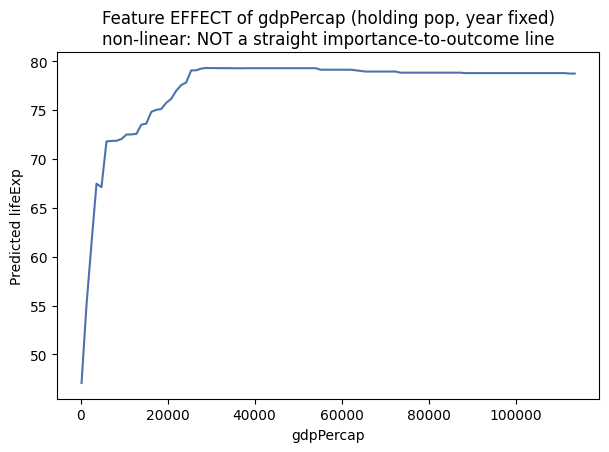

gdpPercap's global IMPORTANCE = 0.837 (highest of all 3 features)
but its EFFECT curve above shows diminishing returns -- 'most important' does not mean
'linearly proportional to the outcome'.


In [ ]:
gdp_range = np.linspace(model_df.gdpPercap.min(), model_df.gdpPercap.max(), 100)
fixed_pop, fixed_year = model_df["pop"].median(), 2000
sweep = np.column_stack([gdp_range, np.full(100, fixed_pop), np.full(100, fixed_year)])
predicted_effect = rf.predict(sweep)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(gdp_range, predicted_effect, color="#4C72B0")
ax.set_xlabel("gdpPercap"); ax.set_ylabel("Predicted lifeExp")
ax.set_title("Feature EFFECT of gdpPercap (holding pop, year fixed)\nnon-linear: NOT a straight importance-to-outcome line")
plt.show()

print(f"gdpPercap's global IMPORTANCE = {importances['gdpPercap']:.3f} (highest of all 3 features)")
print("but its EFFECT curve above shows diminishing returns -- 'most important' does not mean")
print("'linearly proportional to the outcome'.")

## 16. Uncertainty Visualization  *(Slide 25)*

**What:** A plotted value is easily read as precise, even when the underlying estimate
is uncertain (measurement limits, sampling variability, limited data, model/prediction
uncertainty). Ignoring uncertainty makes viewers overestimate precision and make
overconfident comparisons.

**Why:** Below, our own dataset's version of this: 5 African countries' `lifeExp` in
2007 is plotted as bare point estimates — implying total confidence in a single number,
with no indication of how much that estimate might vary.

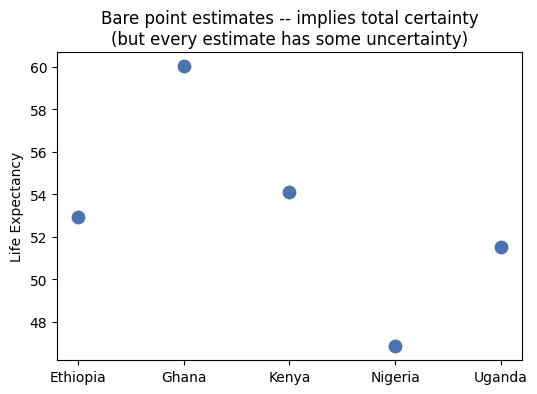

In [ ]:
sample_countries = ["Nigeria", "Kenya", "Ghana", "Ethiopia", "Uganda"]
sample_df = gap_latest[gap_latest.country.isin(sample_countries)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample_df.country, sample_df.lifeExp, s=80, color="#4C72B0")
ax.set_ylabel("Life Expectancy")
ax.set_title("Bare point estimates -- implies total certainty\n(but every estimate has some uncertainty)")
plt.show()

## 17. Variation, Standard Error & Confidence Intervals — Worked Example  *(Slides 26–33)*

**What:** Three DIFFERENT concepts that look visually similar:
- **Standard deviation (SD):** variation among individual observations.
- **Standard error (SE):** precision of an estimated parameter (SE ~= SD / sqrt(n)).
- **Confidence interval (CI):** a range that would contain the true parameter in ~95% of
  repeated samples (Wilke's approximation: mean +/- ~1.96*SE).

**Worked example (reproducing the lecture's exact numbers):** test scores of 5 students:
8, 10, 12, 10, 10.

In [ ]:
scores = np.array([8, 10, 12, 10, 10])
n = len(scores)

mean_score = scores.mean()
print(f"Step 1 -- Mean = {mean_score}")

sd = scores.std(ddof=1)
print(f"Step 2 -- Standard deviation (SD) = {sd:.2f}  (individual scores vary by ~{sd:.2f} points around the mean)")

se = sd / np.sqrt(n)
print(f"Step 3 -- Standard error (SE) = SD/sqrt(n) = {sd:.2f}/sqrt({n}) = {se:.2f}")
print(f"          Notice: SD ({sd:.2f}) > SE ({se:.2f}) -- SD describes the data, SE describes the ESTIMATE.")

ci_margin = 1.96 * se
print(f"\nStep 4 -- Approximate 95% CI = mean +/- 1.96*SE = {mean_score} +/- {ci_margin:.2f}")
print(f"          -> [{mean_score - ci_margin:.2f}, {mean_score + ci_margin:.2f}]")

# Sample size matters: same SD, n=100 instead of 5
se_100 = sd / np.sqrt(100)
ci_100 = 1.96 * se_100
print(f"\nSame SD, but n=100 instead of 5:")
print(f"  SE = {sd:.2f}/sqrt(100) = {se_100:.3f}  (much smaller)")
print(f"  95% CI = {mean_score} +/- {ci_100:.2f} -> [{mean_score-ci_100:.2f}, {mean_score+ci_100:.2f}]  (much narrower)")

Step 1 -- Mean = 10.0
Step 2 -- Standard deviation (SD) = 1.41  (individual scores vary by ~1.41 points around the mean)
Step 3 -- Standard error (SE) = SD/sqrt(n) = 1.41/sqrt(5) = 0.63
          Notice: SD (1.41) > SE (0.63) -- SD describes the data, SE describes the ESTIMATE.

Step 4 -- Approximate 95% CI = mean +/- 1.96*SE = 10.0 +/- 1.24
          -> [8.76, 11.24]

Same SD, but n=100 instead of 5:
  SE = 1.41/sqrt(100) = 0.141  (much smaller)
  95% CI = 10.0 +/- 0.28 -> [9.72, 10.28]  (much narrower)


## 18. Error Bars & Reading Confidence Intervals  *(Slides 34–35)*

**What:** Error bars extend from an estimate to show a range of uncertainty (±1 SD,
±1 SE, 95% CI). **Important caveat:** a 95% CI does NOT mean "95% probability the true
value is in this particular interval" — it means that under repeated sampling, ~95% of
such intervals constructed this way would contain the true value. Visually: wider
interval = more uncertainty, narrower = more precision.

**Why:** Below, our dataset's own confidence intervals — bootstrap-resampled 95% CIs for
mean life expectancy per continent, 2007. Continents with fewer, more variable countries
get wider bars.

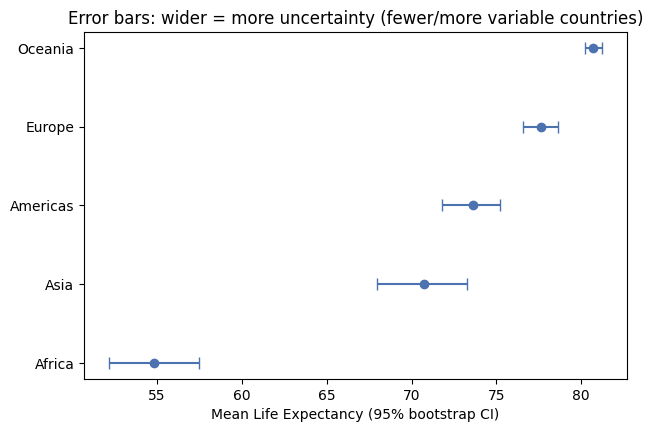

continent  n      mean        lo        hi
   Africa 52 54.806038 52.151851 57.443240
     Asia 33 70.728485 67.941904 73.292786
 Americas 25 73.608120 71.793669 75.230098
   Europe 30 77.648600 76.571597 78.653778
  Oceania  2 80.719500 80.204000 81.235000


In [ ]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return np.mean(values), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

rows = []
for cont, g in gap_latest.groupby("continent"):
    mean, lo, hi = bootstrap_ci(g.lifeExp.values)
    rows.append({"continent": cont, "mean": mean, "lo": lo, "hi": hi, "n": len(g)})
ci_df = pd.DataFrame(rows).sort_values("mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(ci_df["mean"], ci_df.continent, xerr=[ci_df["mean"]-ci_df.lo, ci_df.hi-ci_df["mean"]],
            fmt="o", color="#4C72B0", capsize=4)
ax.set_xlabel("Mean Life Expectancy (95% bootstrap CI)")
ax.set_title("Error bars: wider = more uncertainty (fewer/more variable countries)")
plt.show()

print(ci_df[["continent", "n", "mean", "lo", "hi"]].to_string(index=False))

## 19. Bayesian Uncertainty: Credible Intervals & Distributions  *(Slide 36)*

**What:** A Bayesian analysis represents uncertainty as a **posterior distribution**. A
credible interval describes a region of that distribution (e.g. the central 95%).
Rather than reducing this to one interval, we can visualize the WHOLE distribution:
density plots, violin plots, ridgeline plots, quantile dotplots.

**Why:** Below, instead of a single error bar per continent, the full bootstrap
distribution of mean `lifeExp` is shown as a violin plot — richer than an interval alone,
since it also reveals skew and multimodality.

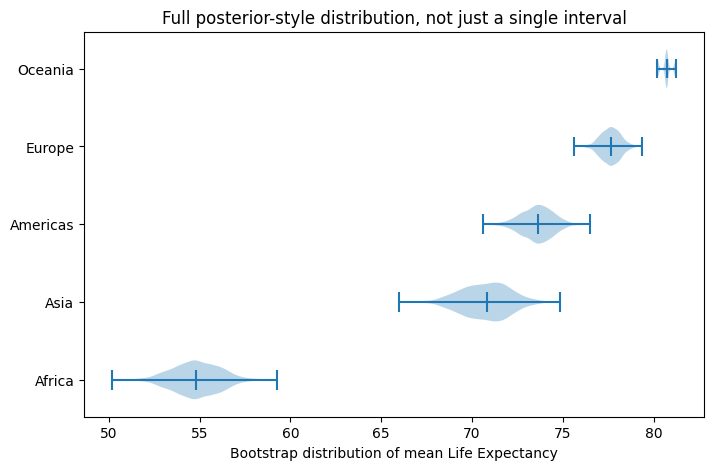

In [ ]:
boot_samples = {}
rng = np.random.default_rng(1)
for cont, g in gap_latest.groupby("continent"):
    boot_samples[cont] = [rng.choice(g.lifeExp.values, size=len(g), replace=True).mean() for _ in range(2000)]

fig, ax = plt.subplots(figsize=(8, 5))
order = ci_df.sort_values("mean").continent.tolist()
data_for_violin = [boot_samples[c] for c in order]
parts = ax.violinplot(data_for_violin, vert=False, showmedians=True)
ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order)
ax.set_xlabel("Bootstrap distribution of mean Life Expectancy")
ax.set_title("Full posterior-style distribution, not just a single interval")
plt.show()

## 20. Uncertainty in Trend Lines  *(Slide 37)*

**What:** A fitted trend is itself an estimate, so it has uncertainty. A **confidence
band** shows the range of plausible fitted values around the line. Even a straight-line
fit produces a CURVED uncertainty band, because both the intercept AND the slope carry
uncertainty — different plausible (intercept, slope) pairs fan out away from the data's
center.

**Why:** Below, a linear trend of world-average `lifeExp` over time, with a bootstrap
confidence band that visibly narrows near the middle of the data and widens at the
edges.

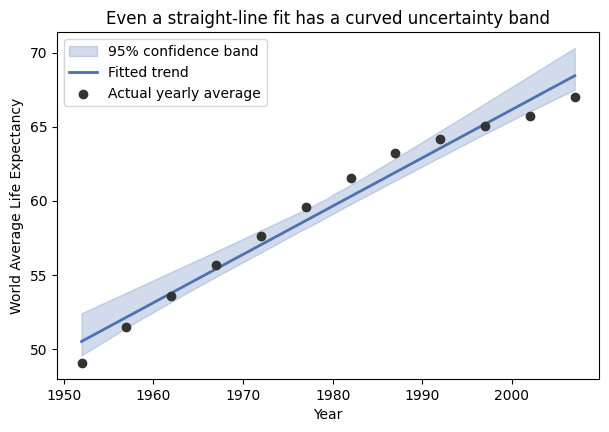

In [ ]:
world_trend = gapminder.groupby("year", as_index=False)["lifeExp"].mean()

boot_lines = []
rng = np.random.default_rng(2)
years_grid = np.linspace(world_trend.year.min(), world_trend.year.max(), 100)
for _ in range(300):
    sample_idx = rng.integers(0, len(world_trend), len(world_trend))
    boot_fit = np.polyfit(world_trend.year.values[sample_idx], world_trend.lifeExp.values[sample_idx], 1)
    boot_lines.append(np.polyval(boot_fit, years_grid))
boot_lines = np.array(boot_lines)
lo_band, hi_band = np.percentile(boot_lines, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(years_grid, lo_band, hi_band, color="#4C72B0", alpha=0.25, label="95% confidence band")
main_fit = np.polyfit(world_trend.year, world_trend.lifeExp, 1)
ax.plot(years_grid, np.polyval(main_fit, years_grid), color="#4C72B0", lw=2, label="Fitted trend")
ax.scatter(world_trend.year, world_trend.lifeExp, color="#333333", zorder=3, label="Actual yearly average")
ax.set_xlabel("Year"); ax.set_ylabel("World Average Life Expectancy")
ax.set_title("Even a straight-line fit has a curved uncertainty band")
ax.legend()
plt.show()

## 21. Communicating Uncertainty Through Possible Outcomes  *(Slide 38)*

**What:** Static uncertainty displays (bands, error bars) can be misread as
deterministic ("the value cannot go outside this bar"). A **Hypothetical Outcome Plot
(HOP)** instead shows many DIFFERENT plausible outcomes, sampled directly from the
uncertainty distribution — making probability feel concrete rather than abstract.

**Why:** Below, instead of one confidence band, we draw 30 individual plausible trend
lines directly from the bootstrap distribution computed in Section 20 — each one is a
genuinely possible version of the true trend.

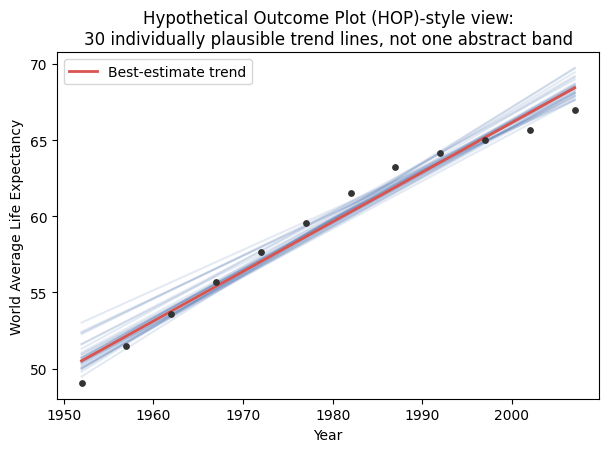

Instead of 'here is THE range of uncertainty', this says 'here are MANY things that
could actually be true' -- which research shows people intuit probability from more easily.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for line in boot_lines[:30]:
    ax.plot(years_grid, line, color="#4C72B0", alpha=0.15)
ax.plot(years_grid, np.polyval(main_fit, years_grid), color="#D9534F", lw=2, label="Best-estimate trend")
ax.scatter(world_trend.year, world_trend.lifeExp, color="#333333", zorder=3, s=15)
ax.set_xlabel("Year"); ax.set_ylabel("World Average Life Expectancy")
ax.set_title("Hypothetical Outcome Plot (HOP)-style view:\n30 individually plausible trend lines, not one abstract band")
ax.legend()
plt.show()

print("Instead of 'here is THE range of uncertainty', this says 'here are MANY things that")
print("could actually be true' -- which research shows people intuit probability from more easily.")

## 22. Interactive Dashboards  *(Slides 39–41)*

**What:** A dashboard is a visual display designed primarily for **monitoring** — status,
key metrics, trends, exceptions, threshold violations. It's not just a collection of
charts; it's designed around a monitoring task, supporting rapid detection of
exceptions, trends, and emerging patterns while the user may be doing something else at
the same time.

**Why:** Below, a compact "world development monitoring" dashboard combines a map, a
trend line, and key numbers — supporting several monitoring questions at once.

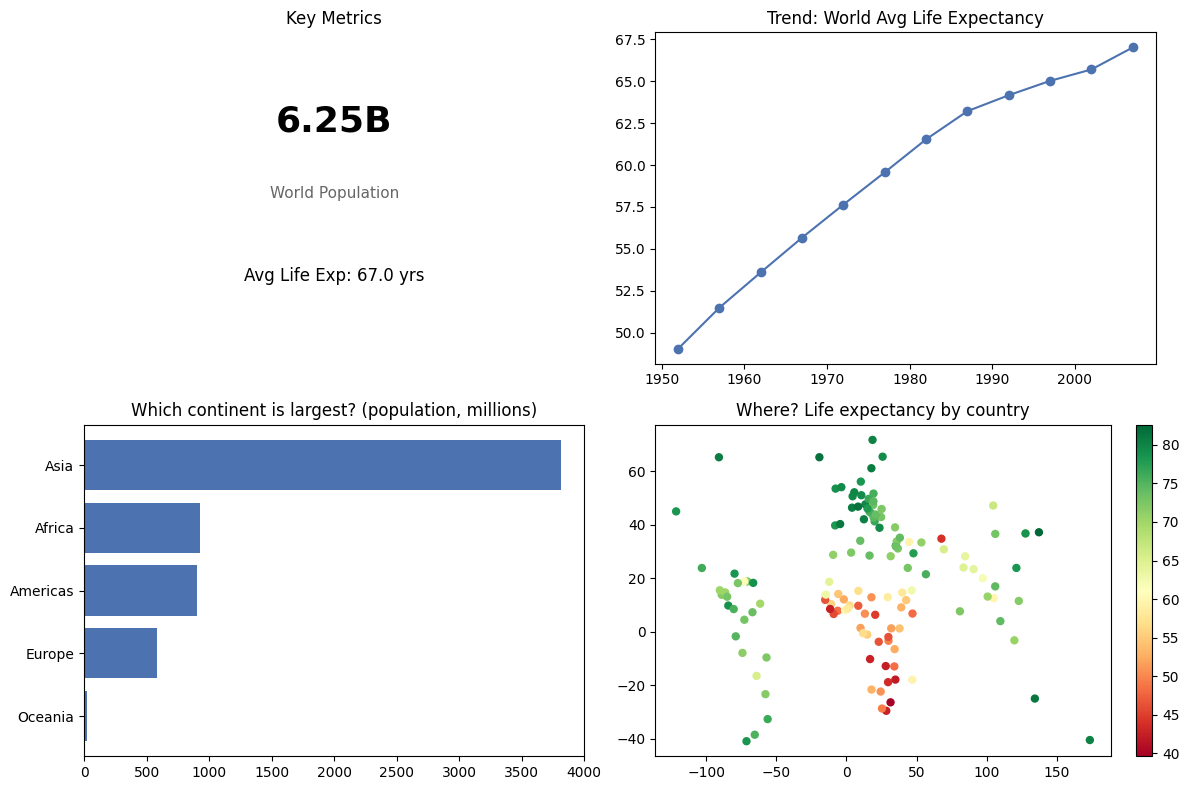

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Key metrics (top-left)
axes[0, 0].axis("off")
latest_year = gapminder.year.max()
world_pop = gapminder[gapminder.year == latest_year]["pop"].sum()
world_life = gapminder[gapminder.year == latest_year]["lifeExp"].mean()
axes[0, 0].text(0.5, 0.7, f"{world_pop/1e9:.2f}B", ha="center", fontsize=26, fontweight="bold")
axes[0, 0].text(0.5, 0.5, "World Population", ha="center", fontsize=11, color="#666666")
axes[0, 0].text(0.5, 0.25, f"Avg Life Exp: {world_life:.1f} yrs", ha="center", fontsize=12)
axes[0, 0].set_title("Key Metrics")

# Trend (top-right)
axes[0, 1].plot(world_trend.year, world_trend.lifeExp, "o-", color="#4C72B0")
axes[0, 1].set_title("Trend: World Avg Life Expectancy")

# Bar chart: which category is largest (bottom-left)
cont_pop = gapminder[gapminder.year == latest_year].groupby("continent")["pop"].sum().sort_values()
axes[1, 0].barh(cont_pop.index, cont_pop.values / 1e6, color="#4C72B0")
axes[1, 0].set_title("Which continent is largest? (population, millions)")

# Map (bottom-right, as a static proxy for the interactive map)
sc = axes[1, 1].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat, c=gap_latest.lifeExp,
                          cmap="RdYlGn", s=25)
axes[1, 1].set_title("Where? Life expectancy by country")
plt.colorbar(sc, ax=axes[1, 1], fraction=0.04)

plt.tight_layout()
plt.show()

## 23. Dashboard Information Density & Composite Visualizations  *(Slides 42–43)*

**What:** A dashboard must balance information availability with cognitive load. Too
little -> inefficient monitoring; too much -> clutter and slower search. A dashboard
combines DIFFERENT visualization types because different views answer different
questions: Map -> Where? Line chart -> How changing? Bar chart -> Which is largest?
Table -> Exact value?

**Why:** Below, the same dashboard from Section 22 is shown at two densities — an
overloaded version with every possible chart crammed in, and a focused version keeping
only what a monitoring task actually needs.

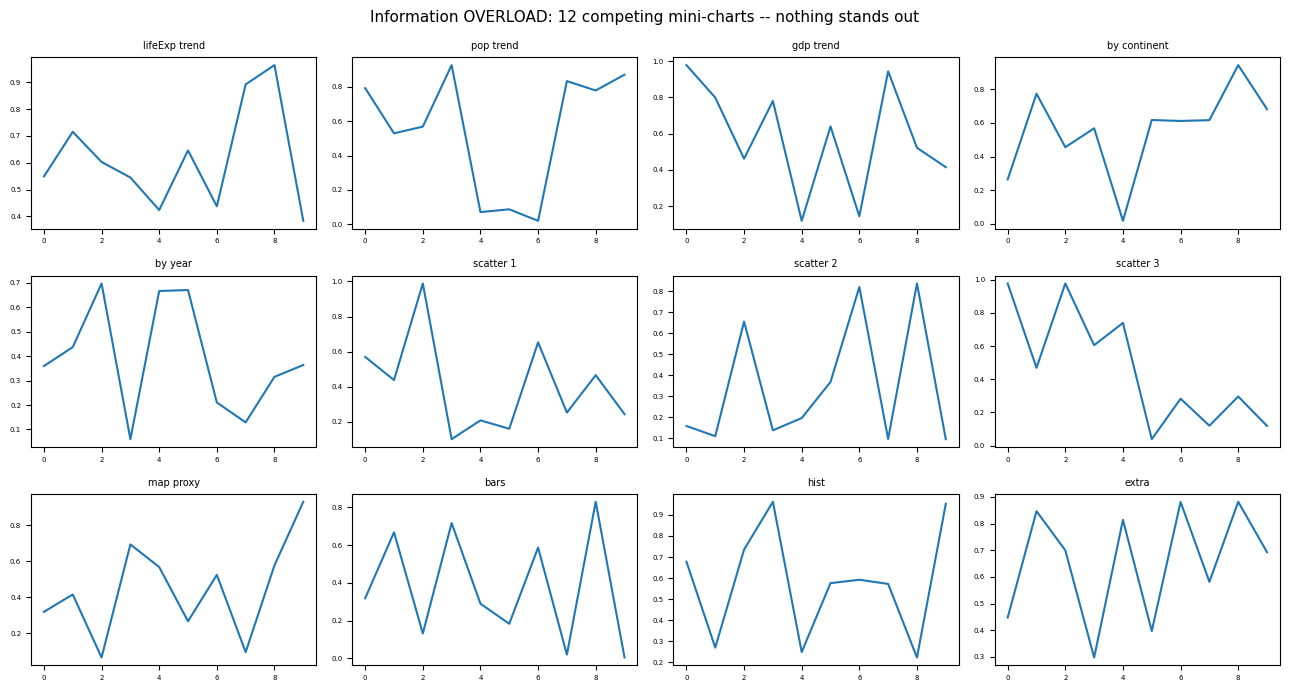

Compare that to Section 22's 4-panel dashboard: same underlying dataset, but focused
on exactly 4 monitoring questions (status, trend, ranking, location) instead of 12.


In [ ]:
fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(3, 4)

# Overloaded panel: too many small, competing charts
titles = ["lifeExp trend", "pop trend", "gdp trend", "by continent",
          "by year", "scatter 1", "scatter 2", "scatter 3", "map proxy", "bars", "hist", "extra"]
for i, t in enumerate(titles):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.plot(np.random.rand(10))
    ax.set_title(t, fontsize=7)
    ax.tick_params(labelsize=5)
plt.suptitle("Information OVERLOAD: 12 competing mini-charts -- nothing stands out", fontsize=11)
plt.tight_layout()
plt.show()

print("Compare that to Section 22's 4-panel dashboard: same underlying dataset, but focused")
print("on exactly 4 monitoring questions (status, trend, ranking, location) instead of 12.")

## 24. Coordinated Multiple Views & Brushing/Linking  *(Slides 44–46)*

**What:**
- **Coordinated Multiple Views (CMV):** several visualizations connected so interacting
  with one affects the others — via shared data, shared encoding, linked selection.
- **Brushing & Linking:** selecting a subset in one view (brushing) automatically
  highlights the corresponding items in every other view (linking) — removing the need
  to mentally match points across separate charts.

**Why:** Below, an interactive widget lets you pick a continent; a map, a scatter plot,
and a trend line all update together — a live demonstration of coordinated views and
linked selection.

In [ ]:
continent_options = ["(All)"] + sorted(gapminder.continent.unique())

@interact(continent=Dropdown(options=continent_options, description="Brush/select:"))
def coordinated_views(continent):
    if continent == "(All)":
        sub_latest = gap_latest
        sub_all = gapminder
    else:
        sub_latest = gap_latest[gap_latest.continent == continent]
        sub_all = gapminder[gapminder.continent == continent]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # View 1: map (highlighted selection)
    axes[0].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat, s=15, color="#dddddd")
    axes[0].scatter(sub_latest.centroid_lon, sub_latest.centroid_lat, s=25, color="#D9534F")
    axes[0].set_title(f"Map: {continent}")

    # View 2: scatter (linked)
    axes[1].scatter(gap_latest.gdpPercap, gap_latest.lifeExp, s=10, color="#dddddd")
    axes[1].scatter(sub_latest.gdpPercap, sub_latest.lifeExp, s=20, color="#D9534F")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("GDP per capita (log)"); axes[1].set_ylabel("Life Expectancy")
    axes[1].set_title("Scatter: linked selection")

    # View 3: trend (linked)
    trend = sub_all.groupby("year", as_index=False)["lifeExp"].mean()
    axes[2].plot(trend.year, trend.lifeExp, "o-", color="#D9534F")
    axes[2].set_title(f"Trend: {continent}")

    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Brush/select:', options=('(All)', 'Africa', 'Americas', 'Asia', 'E…

## Summary: Technique -> When to Use It

| Technique | Solves | Use it when... |
|---|---|---|
| Point / symbol map | Show exact locations + extra attributes | Individual observations at known coordinates matter |
| Choropleth (as a RATE, not a count) | Regional comparison | Comparing a normalized quantity by region |
| Cartogram | Population/data dominates over geography | You want data magnitude, not land area, to be visually salient |
| Global feature importance | Understand a model overall | Feature selection, comparing overall reliance on inputs |
| Local (SHAP) feature importance | Explain one prediction | Investigating a specific/unusual prediction |
| Error bars / CI | Show precision of an estimate | Any point estimate that came from a sample |
| Confidence band on a trend | Show a fitted line's own uncertainty | Regression/trend fitting |
| Hypothetical Outcome Plot | Avoid deterministic misreading | Communicating probability to a general audience |
| Coordinated multiple views + brushing | Multi-question monitoring | A dashboard needs several linked perspectives on one dataset |

**Core principle:** every value on screen carries some degree of uncertainty, every map
has a projection/aggregation choice baked in, and every model has explanations that only
become legible once the numbers are turned into position, length, and color.